## Movie-Regressor

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import random


In [2]:
df = pd.read_parquet("../data/movies_cleaned.parquet.gzip", engine='pyarrow')
df.head()

,RATING,VOTES,RunTime,TYPE,YEAR_FROM,YEAR_TO,GENRE_Action,GENRE_Adventure,GENRE_Animation,GENRE_Biography,...,Director_Àlex Pastor,Director_Álex de la Iglesia,Director_Álvaro Brechner,Director_Álvaro Fernández Armero,Director_Álvaro Longoria,Director_Ángel Gómez Hernández,Director_Ángeles Reiné,Director_Åke Sandgren,Director_Óscar Pedraza,Director_Ömer Ugur
0,6.1,21062,121.0,Movie,2021,2021,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5.0,17870,25.0,Series,2021,2026,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
2,8.2,885805,44.0,Series,2010,2022,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9.2,414849,23.0,Series,2013,2026,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
5,7.6,25858,50.0,Series,2020,2026,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.shape

(8168, 21441)

One-hot Encoding

In [4]:
df["TYPE"] = np.where(df["TYPE"] == "Movie", 1, 0)
df.head() 

,RATING,VOTES,RunTime,TYPE,YEAR_FROM,YEAR_TO,GENRE_Action,GENRE_Adventure,GENRE_Animation,GENRE_Biography,...,Director_Àlex Pastor,Director_Álex de la Iglesia,Director_Álvaro Brechner,Director_Álvaro Fernández Armero,Director_Álvaro Longoria,Director_Ángel Gómez Hernández,Director_Ángeles Reiné,Director_Åke Sandgren,Director_Óscar Pedraza,Director_Ömer Ugur
0,6.1,21062,121.0,1,2021,2021,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5.0,17870,25.0,0,2021,2026,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
2,8.2,885805,44.0,0,2010,2022,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9.2,414849,23.0,0,2013,2026,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
5,7.6,25858,50.0,0,2020,2026,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.sample(5)

,RATING,VOTES,RunTime,TYPE,YEAR_FROM,YEAR_TO,GENRE_Action,GENRE_Adventure,GENRE_Animation,GENRE_Biography,...,Director_Àlex Pastor,Director_Álex de la Iglesia,Director_Álvaro Brechner,Director_Álvaro Fernández Armero,Director_Álvaro Longoria,Director_Ángel Gómez Hernández,Director_Ángeles Reiné,Director_Åke Sandgren,Director_Óscar Pedraza,Director_Ömer Ugur
9394,7.1,34,26.0,0,2021,2026,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2433,6.5,5503,100.0,1,2014,2014,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7781,8.9,3141,40.0,0,2019,2026,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1436,5.8,35113,89.0,1,2019,2019,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7611,8.0,634,49.0,1,2021,2021,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


StandardScaler

In [6]:
column_names = ["YEAR_FROM", "YEAR_TO", "RunTime"]
scaler = StandardScaler()
df[column_names] = scaler.fit_transform(df[column_names])
df.head()


,RATING,VOTES,RunTime,TYPE,YEAR_FROM,YEAR_TO,GENRE_Action,GENRE_Adventure,GENRE_Animation,GENRE_Biography,...,Director_Àlex Pastor,Director_Álex de la Iglesia,Director_Álvaro Brechner,Director_Álvaro Fernández Armero,Director_Álvaro Longoria,Director_Ángel Gómez Hernández,Director_Ángeles Reiné,Director_Åke Sandgren,Director_Óscar Pedraza,Director_Ömer Ugur
0,6.1,21062,1.218010,1,0.681572,0.265713,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5.0,17870,-0.931818,0,0.681572,0.862455,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
2,8.2,885805,-0.506331,0,-0.772734,0.385062,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9.2,414849,-0.976606,0,-0.376105,0.862455,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
5,7.6,25858,-0.371967,0,0.549363,0.862455,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
#Drop VOTES
df = df.drop(columns=["VOTES"])
df.head()

,RATING,RunTime,TYPE,YEAR_FROM,YEAR_TO,GENRE_Action,GENRE_Adventure,GENRE_Animation,GENRE_Biography,GENRE_Comedy,...,Director_Àlex Pastor,Director_Álex de la Iglesia,Director_Álvaro Brechner,Director_Álvaro Fernández Armero,Director_Álvaro Longoria,Director_Ángel Gómez Hernández,Director_Ángeles Reiné,Director_Åke Sandgren,Director_Óscar Pedraza,Director_Ömer Ugur
0,6.1,1.218010,1,0.681572,0.265713,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5.0,-0.931818,0,0.681572,0.862455,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,8.2,-0.506331,0,-0.772734,0.385062,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9.2,-0.976606,0,-0.376105,0.862455,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
5,7.6,-0.371967,0,0.549363,0.862455,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df.dtypes

RATING                            float64
RunTime                           float64
TYPE                                int64
YEAR_FROM                         float64
YEAR_TO                           float64
                                   ...   
Director_Ángel Gómez Hernández      int64
Director_Ángeles Reiné              int64
Director_Åke Sandgren               int64
Director_Óscar Pedraza              int64
Director_Ömer Ugur                  int64
Length: 21440, dtype: object

Train/Test Split

In [9]:
x = df.drop(columns=["RATING"])
y = df["RATING"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"x_train shape: {x_train.shape}, x_test shape: {x_test.shape}")

x_train shape: (6534, 21439), x_test shape: (1634, 21439)


Regressor

In [10]:
model = MLPRegressor(hidden_layer_sizes=(100, 50, 25), activation='relu', solver='adam', 
                    alpha=0.001, early_stopping=True, n_iter_no_change=30, validation_fraction=0.1, 
                    max_iter=1000, verbose=True, random_state=42, learning_rate_init=0.05)
model.fit(x_train, y_train)

Iteration 1, loss = 6.72591315
Validation score: -0.136332
Iteration 2, loss = 0.82496792
Validation score: 0.281991
Iteration 3, loss = 0.38684504
Validation score: 0.424211
Iteration 4, loss = 0.26075111
Validation score: 0.326606
Iteration 5, loss = 0.20121657
Validation score: 0.425757
Iteration 6, loss = 0.16670205
Validation score: 0.465331
Iteration 7, loss = 0.14411258
Validation score: 0.455128
Iteration 8, loss = 0.13176973
Validation score: 0.433113
Iteration 9, loss = 0.12544129
Validation score: 0.454313
Iteration 10, loss = 0.12024695
Validation score: 0.462898
Iteration 11, loss = 0.12016806
Validation score: 0.426318
Iteration 12, loss = 0.11850072
Validation score: 0.471599
Iteration 13, loss = 0.11748296
Validation score: 0.474666
Iteration 14, loss = 0.11262836
Validation score: 0.483747
Iteration 15, loss = 0.10834124
Validation score: 0.476149
Iteration 16, loss = 0.10377191
Validation score: 0.484733
Iteration 17, loss = 0.10248993
Validation score: 0.476790
Itera

,loss,'squared_error'
,hidden_layer_sizes,"(100, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.05
,power_t,0.5
,max_iter,1000
,shuffle,True


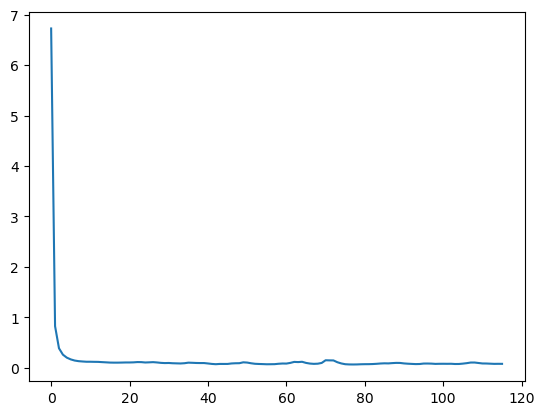

In [11]:
loss_curve = model.loss_curve_
plt.plot(loss_curve)
plt.show()

Evaluation

In [12]:
#Train

y_pred = model.predict(x_train)
mse_train = mean_squared_error(y_train, y_pred)
mae_train = mean_absolute_error(y_train, y_pred)
rmse_train = np.sqrt(mse_train)

print(f"Train MSE: {mse_train:.4f}")
print(f"Train MAE: {mae_train:.4f}")
print(f"Train RMSE: {rmse_train:.4f}")

Train MSE: 0.1586
Train MAE: 0.2536
Train RMSE: 0.3983


In [13]:
#Test
y_pred = model.predict(x_test)
mse_test = mean_squared_error(y_test, y_pred)
mae_test = mean_absolute_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)

print(f"Test MSE: {mse_test:.4f}")
print(f"Test MAE: {mae_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")


Test MSE: 0.8634
Test MAE: 0.6915
Test RMSE: 0.9292


In [14]:
df_pred = pd.DataFrame(y_pred, columns=["Predicted_Rating"])
df_pred.describe()

,Predicted_Rating
count,1634.000000
mean,6.937507
std,0.872797
min,3.022847
25%,6.350892
50%,6.914104
75%,7.478418
max,9.720572


In [15]:
df[["RATING"]].describe()

,RATING
count,8168.000000
mean,6.921658
std,1.219852
min,1.100000
25%,6.200000
50%,7.100000
75%,7.800000
max,9.900000


Random Prediction

In [16]:
actual = df["RATING"]
y_pred = []
for i in range(len(actual)):
    n = random.randint(1,10)
    y_pred.append(n)

mse_random = mean_squared_error(actual, y_pred)
mae_random = mean_absolute_error(actual, y_pred)
rmse_random = np.sqrt(mse_random)

print(f"Random MSE: {mse_random:.4f}")
print(f"Random MAE: {mae_random:.4f}")
print(f"Random RMSE: {rmse_random:.4f}")


Random MSE: 11.8184
Random MAE: 2.8460
Random RMSE: 3.4378


Random Prediction (6,8)

In [17]:
y_pred = []
for i in range(len(actual)):
    n = random.randint(6,8)
    y_pred.append(n)

mse_random = mean_squared_error(actual, y_pred)
mae_random = mean_absolute_error(actual, y_pred)
rmse_random = np.sqrt(mse_random)

print(f"Random MSE: {mse_random:.4f}")
print(f"Random MAE: {mae_random:.4f}")
print(f"Random RMSE: {rmse_random:.4f}")

Random MSE: 2.1641
Random MAE: 1.1712
Random RMSE: 1.4711


Rating: 6.9

In [18]:
y_pred = df.shape[0] * [6.9]

mse_mean = mean_squared_error(actual, y_pred)
mae_mean = mean_absolute_error(actual, y_pred)
rmse_mean = np.sqrt(mse_mean)

print(f"Mean MSE: {mse_mean:.4f}")
print(f"Mean MAE: {mae_mean:.4f}")
print(f"Mean RMSE: {rmse_mean:.4f}")

Mean MSE: 1.4883
Mean MAE: 0.9589
Mean RMSE: 1.2200


In [19]:
series_mean_rating = df.loc[df["TYPE"] == 0, "RATING"].mean()
movie_mean_rating = df.loc[df["TYPE"] == 1, "RATING"].mean()
print(f"Series Mean Rating: {series_mean_rating:.4f}")
print(f"Movie Mean Rating: {movie_mean_rating:.4f}")


Series Mean Rating: 7.4178
Movie Mean Rating: 6.4891


Movie: 6.4 / Series: 7.4

In [20]:
df["prediction"] = np.where(df["TYPE"] == 1, movie_mean_rating, series_mean_rating)
y_pred = df["prediction"]

mse_type = mean_squared_error(actual, y_pred)
mae_type = mean_absolute_error(actual, y_pred)
rmse_type = np.sqrt(mse_type)

print(f"Type MSE: {mse_type:.4f}")
print(f"Type MAE: {mae_type:.4f}")
print(f"Type RMSE: {rmse_type:.4f}")

Type MSE: 1.2732
Type MAE: 0.8753
Type RMSE: 1.1284
